<h3> Informações Iniciais para Realização da Atividade 2</h3>
 
<ul>
<li><b>Predict Students' Dropout and Academic Success</li>
<li><b>URL:</b> 
<a href="https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success" target="_blank">
https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success
</a>
</li>
<li><b>Número de Colunas (Atributos):</b> 36</li>
<li><b>Número de Objetos (Instâncias):</b> 4424</li>
<li><b>Número de Rótulos:</b> 1</li>
<li><b>Possui dados faltantes:</b> Não</li>
<li><b>Possui dados categóricos:</b> Sim</li>
</ul>

<p style="text-align: justify;">
  O código completo apresentado abaixo corresponde à etapa inicial do processo de Mineração de Dados, tendo como foco a leitura e visualização de um dataset, bem como a normalização dos dados e verificação da correlação entre os campos presentes no Dataset escolhido, visto que a limpeza não é necessária devido à falta de dados nulos ou duvidosos. Essas etapas são fundamentais para garantir maior qualidade e confiabilidade nas análises realizadas nas fases seguintes do processo de mineração de dados.
</p>

<p style="text-align: justify;">
  Essa etapa torna-se necessária devido à grande quantidade de informações coletadas atualmente em diversos setores da sociedade, especialmente por grandes empresas de tecnologia (Big Techs). Entretanto, nem todos os dados coletados são necessariamente úteis ou relevantes para a análise proposta. Assim, o processo de tratamento de dados tem como objetivo filtrar definir a relação entre as variáveis utilizando a matriz de correlação e filtrar variáveis relevantes por meio do método de Análise de Componentes Principais (PCA), visto em sala de aula.
</p>

In [4]:

# Importação da biblioteca pandas para manipulação de DataFrames, seaborn para criação do heatmap da matriz de correlação, 
# Importação do matplotlib para exibição em gráfico e do sklearn para normalização dos dados e implementação do método PCA.
# Importação de plotly.express para plotagem de gráfico pca em 3D.

import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler


In [5]:

# Leitura do arquivo .csv por meio da biblioteca pandas e atribuição à variável processed_students_df para manipulação dos dados
original_students_df = pd.read_csv("predict_students_dropout_and_academic_success.csv", sep = ";")
processed_students_df = original_students_df.copy()


In [6]:
original_students_df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [7]:

# Verificação do desbalanceamento do rótulo Target para futuras análises de resultados
print(original_students_df["Target"].value_counts())


Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


<p style="text-align: justify;"> 
    A análise do desbalanceamento da classe "Target" é fundamental nas etapas iniciais de um processo de mineração de dados, uma vez que, ao aplicar posteriormente técnicas de Machine Learning (possivelmente de classificação, neste caso), a distribuição desigual entre os rótulos pode impactar diretamente o desempenho do modelo. Em cenários ideais, as classes deveriam apresentar uma distribuição equilibrada, com aproximadamente 33% das instâncias para cada rótulo. Entretanto, observa-se um desbalanceamento significativo no dataset selecionado. Considerando os 4424 registros de estudantes coletados, a distribuição das classes é a seguinte:

<li>Classificação: Formado - Instâncias: 2209 - Porcentagem: 49,9%</li>
<li>Classificação: Desistente - Instâncias: 1421 - Porcentagem: 32,1%</li> 
<li>Classificação: Matriculado - Instâncias: 794 - Porcentagem: 17,9%</li> 
</p>

In [8]:

# Separação da coluna com rótulo "Target" do resto do dataset para uso futuro
y = original_students_df["Target"];
processed_students_df.drop("Target", axis = 1, errors = "ignore", inplace = True)
processed_students_df.columns = processed_students_df.columns.str.strip()


<p style="text-align: justify;"> 
    O rótulo "Target" foi removido do DataFrame utilizado para a visualização da matriz de correlação, visto que essa análise deve considerar apenas variáveis numéricas. Além disso, a remoção também se mostrou necessária para a aplicação do método PCA, empregado na redução de dimensionalidade com o objetivo de preservar o máximo de informação possível, uma vez que o rótulo da classe não deve ser incluído nesse processo.
</p>

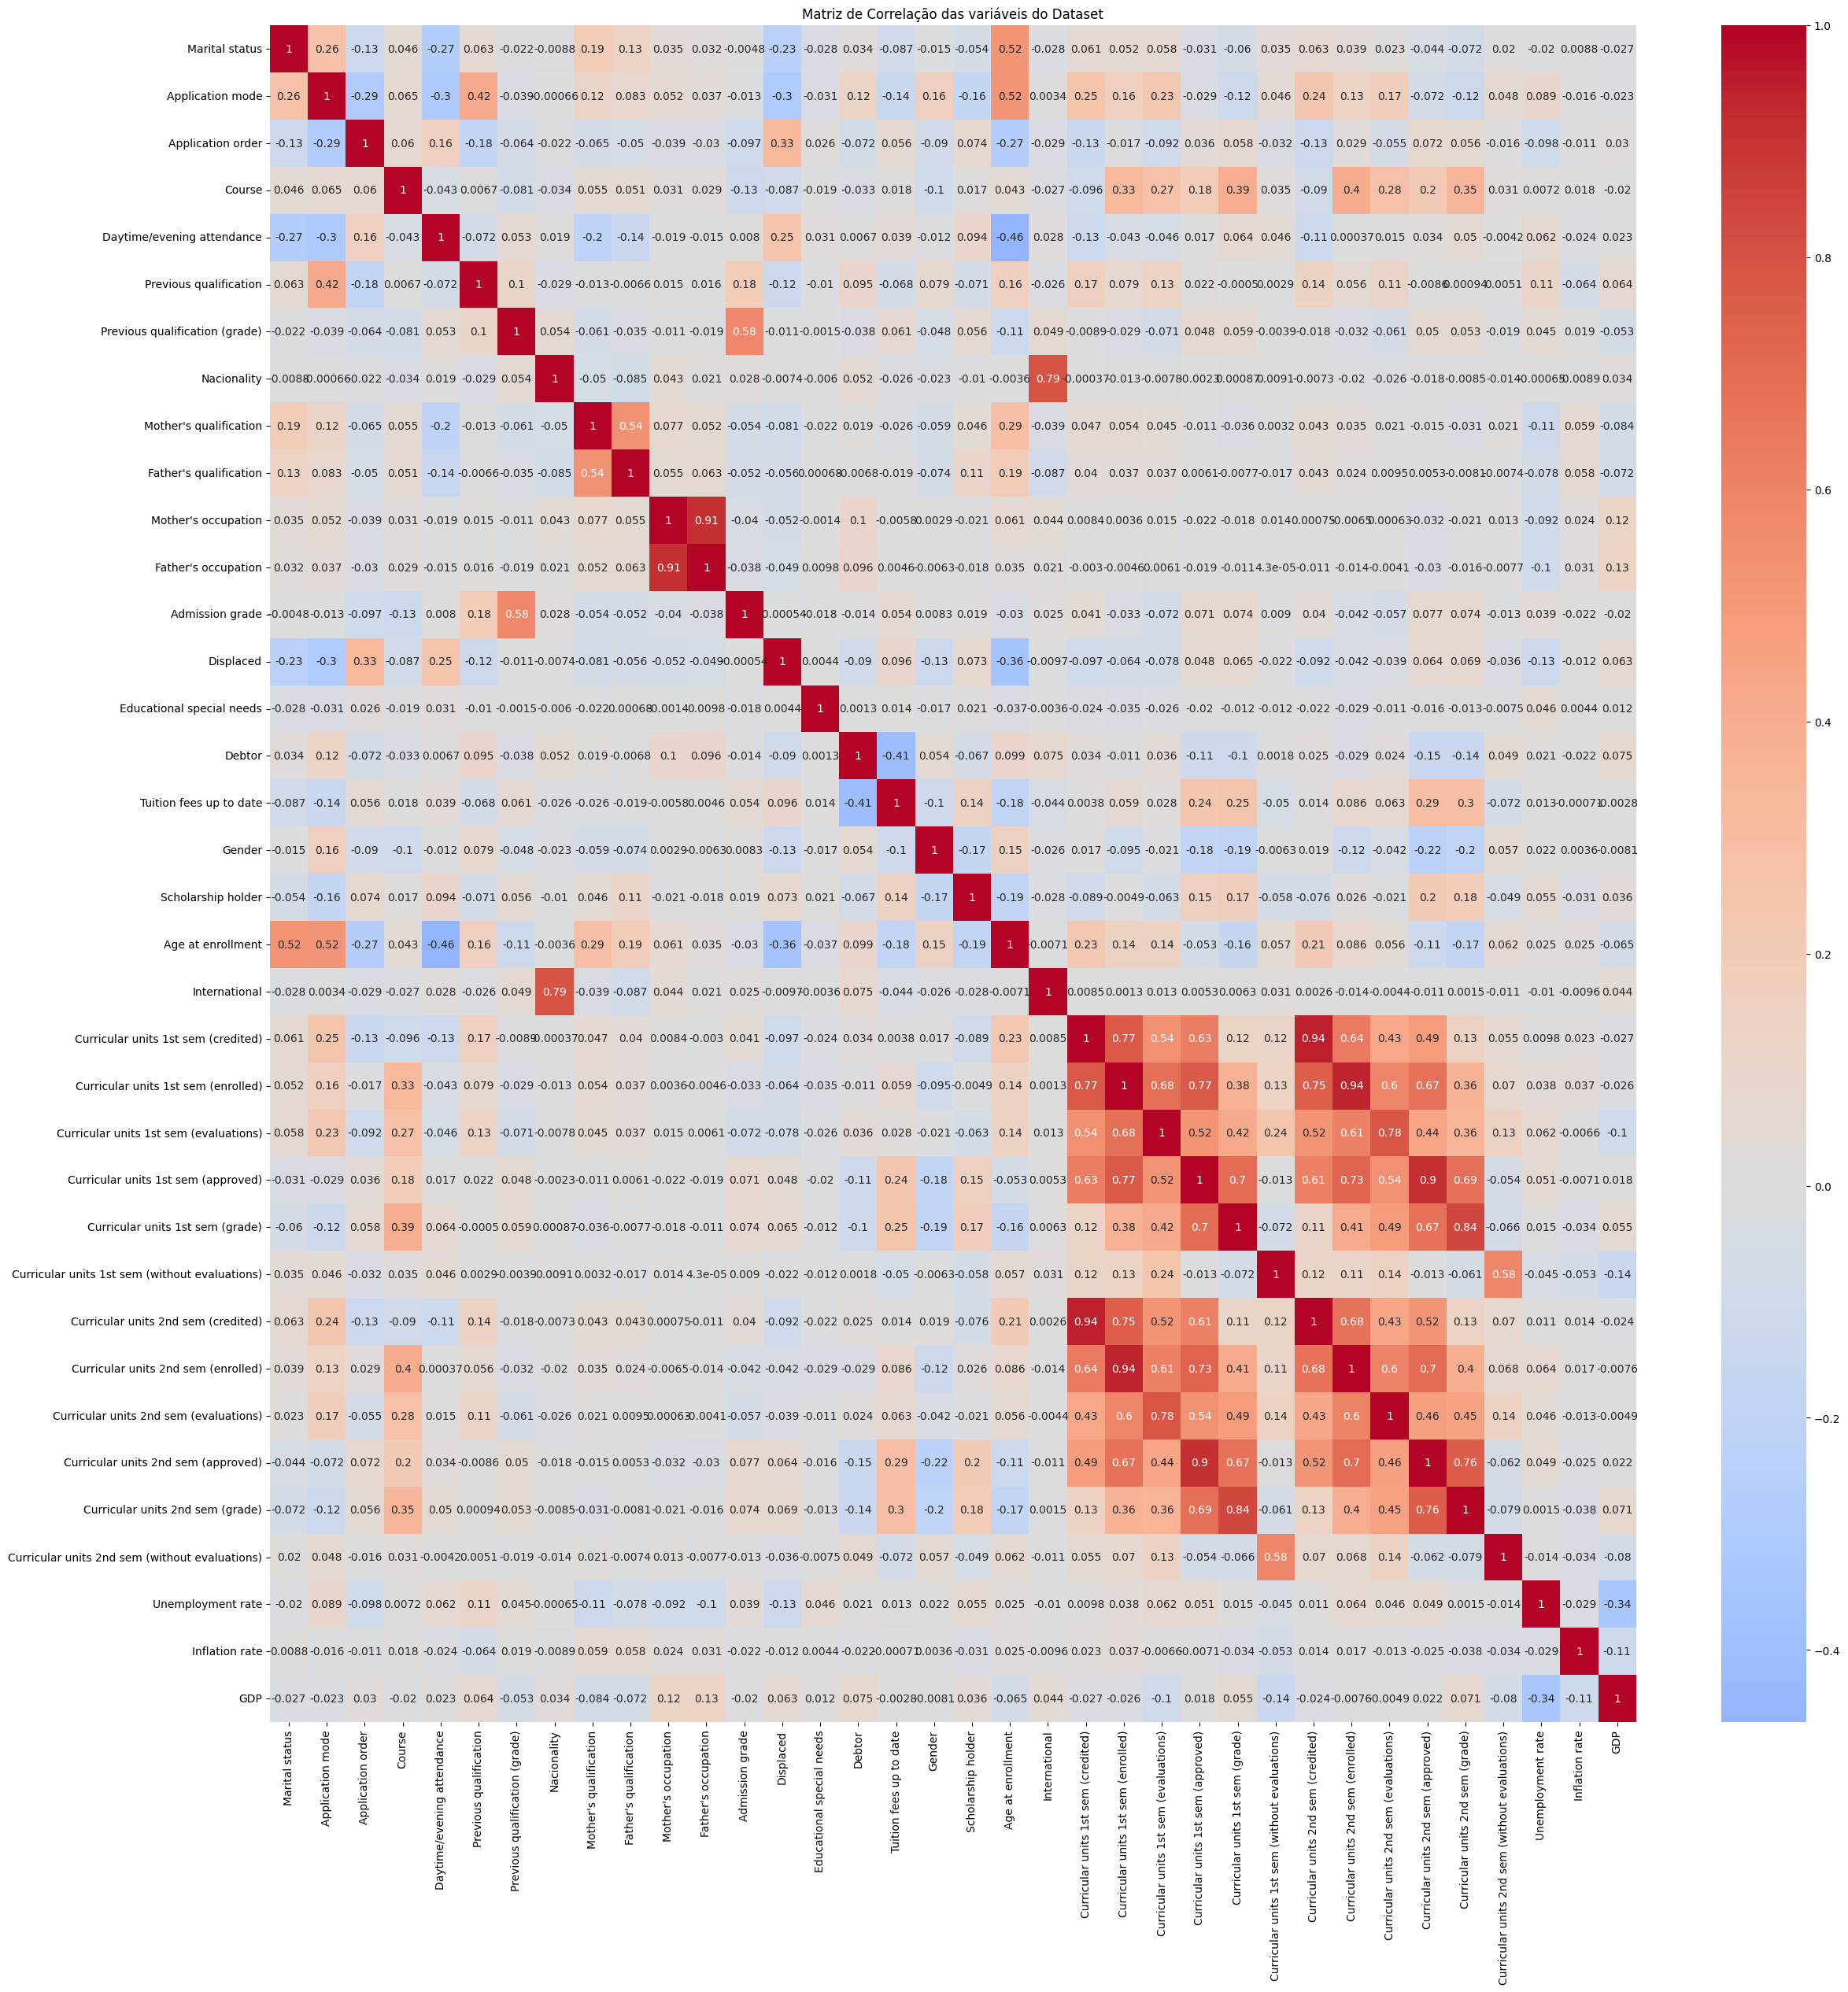

In [9]:

# Matriz de correlação entre os campos dos dados
correlation_matrix = processed_students_df.corr()
plt.figure(figsize = (28, 28))
sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm', center = 0)
plt.title('Matriz de Correlação das variáveis do Dataset')
plt.show()


<p style="text-align: justify">
    A matriz de correlação apresentada acima evidencia o grau de relacionamento linear entre as variáveis do dataset analisado. Valores positivos indicam correlação positiva, ou seja, as variáveis tendem a variar na mesma direção, enquanto valores negativos indicam correlação negativa, significando que, à medida que uma variável aumenta, a outra tende a diminuir. De modo geral, observa-se que a maior parte das variáveis apresenta baixa correlação linear. Entretanto, pares como "Mother Occupation" e "Father Occupation", bem como "Curricular Units 1st sem" e "Curricular Units 2nd sem", exibem alta correlação positiva, o que pode indicar a presença de informações redundantes ou fortemente relacionadas em diferentes colunas do dataset original.
</p>

In [10]:

# Normalização dos dados com min. máx. para usar método PCA
scaler = MinMaxScaler()
scaled_students_df = pd.DataFrame(scaler.fit_transform(processed_students_df), columns = processed_students_df.columns)
scaled_students_df.head(10)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
0,0.0,0.285714,0.555556,0.013858,1.0,0.000000,0.284211,0.000000,0.418605,0.255814,...,0.0,0.0,0.000000,0.000000,0.00,0.000000,0.000000,0.372093,0.488889,0.766182
1,0.0,0.250000,0.111111,0.925989,1.0,0.000000,0.684211,0.000000,0.000000,0.046512,...,0.0,0.0,0.260870,0.181818,0.30,0.735897,0.000000,0.732558,0.111111,0.640687
2,0.0,0.000000,0.555556,0.907512,1.0,0.000000,0.284211,0.000000,0.837209,0.837209,...,0.0,0.0,0.260870,0.000000,0.00,0.000000,0.000000,0.372093,0.488889,0.766182
3,0.0,0.285714,0.222222,0.978108,1.0,0.000000,0.284211,0.000000,0.860465,0.837209,...,0.0,0.0,0.260870,0.303030,0.25,0.667692,0.000000,0.209302,0.000000,0.124174
4,0.2,0.678571,0.111111,0.801466,0.0,0.000000,0.052632,0.000000,0.837209,0.860465,...,0.0,0.0,0.260870,0.181818,0.30,0.700000,0.000000,0.732558,0.111111,0.640687
5,0.2,0.678571,0.111111,1.000000,0.0,0.428571,0.401053,0.000000,0.837209,0.837209,...,0.0,0.0,0.217391,0.515152,0.25,0.619231,0.416667,1.000000,0.244444,0.414795
6,0.0,0.000000,0.111111,0.950693,1.0,0.000000,0.494737,0.000000,0.418605,0.860465,...,0.0,0.0,0.347826,0.242424,0.40,0.772423,0.000000,0.918605,0.800000,0.000000
7,0.0,0.303571,0.444444,0.925989,1.0,0.000000,0.252632,0.000000,0.837209,0.837209,...,0.0,0.0,0.217391,0.151515,0.00,0.000000,0.000000,0.918605,0.800000,0.000000
8,0.0,0.000000,0.333333,0.924382,1.0,0.000000,0.442105,0.564815,0.000000,0.000000,...,0.0,0.0,0.260870,0.212121,0.30,0.761538,0.000000,1.000000,0.244444,0.414795
9,0.0,0.000000,0.111111,0.924382,1.0,0.000000,0.452632,0.000000,0.000000,0.418605,...,0.0,0.0,0.260870,0.424242,0.10,0.726923,0.000000,0.151163,0.488889,1.000000


<p style="text-align: justify">
    Devido à diferença de escala entre as variáveis do dataset, tornou-se necessária a normalização dos dados antes da aplicação do método PCA, visto que essa técnica é sensível à magnitude dos atributos. O PCA tem como objetivo reduzir a dimensionalidade do conjunto de dados por meio da construção de novas componentes principais, capazes de concentrar a maior parte da variância presente nas variáveis originais, preservando o máximo de informação possível. Dessa forma, o método foi aplicado considerando 2 e 3 componentes principais, permitindo visualizações bidimensionais e tridimensionais dos dados, sendo a representação 3D disponibilizada por meio de um arquivo HTML separado.
</p>

Explained variance per component:
[0.1621740630313299, 0.12121721914363247]




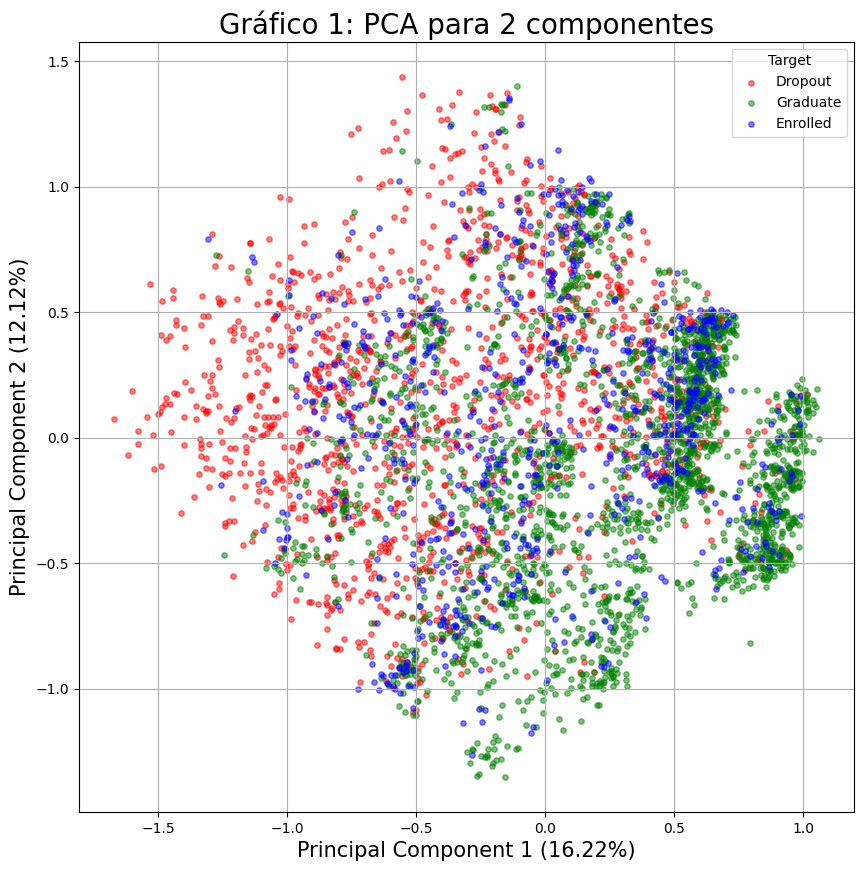

In [15]:

pca = PCA(n_components = 2)
principalComponents = pca.fit_transform(scaled_students_df)

print("Explained variance per component:")
print(pca.explained_variance_ratio_.tolist())
print("\n")

pca_df = pd.DataFrame(data = principalComponents[:, 0:2], columns = ['principal component 1', 'principal component 2'])
final_df = pd.concat([pca_df, y.reset_index(drop = True)], axis = 1)


fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)
ax.set_xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)', fontsize = 15)
ax.set_ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)', fontsize = 15)
ax.set_title('Gráfico 1: PCA para 2 componentes', fontsize = 20)

targets = final_df[y.name].unique()
colors = ['r', 'g', 'b']

for classe, color in zip(targets, colors):
    indicesToKeep = final_df[y.name] == classe
    ax.scatter(
        final_df.loc[indicesToKeep, 'principal component 1'],
        final_df.loc[indicesToKeep, 'principal component 2'],
        c = color,
        s = 15,
        alpha = 0.5,
        label = classe
    )

ax.legend(title = y.name)
ax.grid()
plt.show()


<p style="text-align: justify">
    A aplicação do PCA com 2 componentes principais possibilitou a projeção do conjunto de dados em um espaço bidimensional, favorecendo a análise visual da distribuição das classes da variável "Target". No entanto, as duas primeiras componentes principais explicam apenas aproximadamente 28,34% da variância total dos dados (16,22% + 12,12%), valor relativamente baixo para uma representação reduzida. Como consequência, observa-se uma sobreposição significativa entre as classes "Dropout", "Graduate" e "Enrolled", especialmente na região central do gráfico, dificultando a identificação de agrupamentos bem definidos. Isso indica que, embora o método tenha sido útil como ferramenta de análise exploratória e redução de dimensionalidade, sua eficácia na separação visual das classes mostrou-se limitada. Tal resultado é coerente com a natureza não supervisionada do PCA, que busca maximizar a variância dos dados e não necessariamente a discriminação entre os rótulos.
</p>

Explained variance per component:
[0.1621740630313299, 0.12121721914363247, 0.09360490320623654]
Arquivo HTML criado com sucesso!


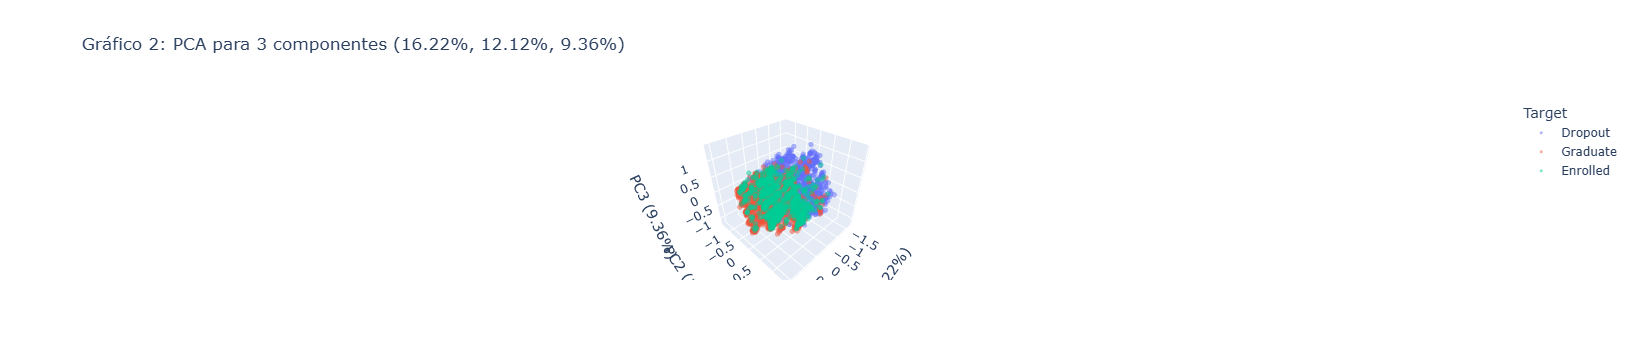

In [12]:

pca = PCA(n_components = 3)
principalComponents = pca.fit_transform(scaled_students_df)

print("Explained variance per component:")
print(pca.explained_variance_ratio_.tolist())
pca_df = pd.DataFrame(
    data = principalComponents,
    columns = ['principal component 1', 'principal component 2', 'principal component 3']
)

final_df = pd.concat([pca_df, y.reset_index(drop = True)], axis = 1)

fig = px.scatter_3d(
    final_df,
    x = 'principal component 1',
    y = 'principal component 2',
    z = 'principal component 3',
    color = y.name,
    opacity = 0.5,
    title = (
        f'Gráfico 2: PCA para 3 componentes '
        f'({pca.explained_variance_ratio_[0]*100:.2f}%, '
        f'{pca.explained_variance_ratio_[1]*100:.2f}%, '
        f'{pca.explained_variance_ratio_[2]*100:.2f}%)'
    )
)

fig.update_traces(marker = dict(size = 3))

fig.update_layout(
    scene = dict(
        xaxis_title = f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)',
        yaxis_title = f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)',
        zaxis_title = f'PC3 ({pca.explained_variance_ratio_[2]*100:.2f}%)'
    )
)

fig.write_html("grafico_pca_3d.html")
print("Arquivo HTML criado com sucesso!")
fig.show()

<p style="text-align: justify;">
A aplicação do método PCA mostrou-se útil para fins de visualização e redução de dimensionalidade do dataset, permitindo projetar os dados em 2 e 3 componentes principais. No caso de 2 componentes, a variância explicada acumulada foi de 28,34%, enquanto para 3 componentes esse valor aumentou para 37,70% (9.36% a mais), evidenciando que a terceira componente adiciona informação relevante à representação dos dados. Apesar disso, observa-se que as classes ainda apresentam considerável sobreposição, o que indica que a separação entre os rótulos não é fortemente linear nas primeiras componentes principais. Dessa forma, conclui-se que o PCA foi eficaz como técnica de análise exploratória e visualização, porém limitado para promover uma separação clara entre as classes do problema.
</p>

<h3>Referências</h3>

<p style="text-align: justify; margin-bottom: 12px;">
CASTRO, Leandro Nunes de; FERRARI, Daniel Gomes. <b>Introdução à mineração de dados: conceitos básicos, algoritmos e aplicações.</b> São Paulo: Saraiva, 2016.
</p>

<p style="text-align: justify; margin-bottom: 12px;">
M.V.Martins, D. Tolledo, J. Machado, L. M.T. Baptista, V.Realinho. (2021) <b>"Early prediction of student’s performance in higher education: a case study" Trends and Applications in Information Systems and Technologies</b>, vol.1, in Advances in Intelligent Systems and Computing series. Springer. DOI: 10.1007/978-3-030-72657-7_16. Acesso em: 8 mar. 2026.
</p>

<p style="text-align: justify; margin-bottom: 12px;">
STATPLACE. <b>Análise de Componentes Principais: o que é, como funciona e exemplos.</b> YouTube. Disponível em: <a href="https://www.youtube.com/watch?v=cOCeXgMKrY8" target="_blank">https://www.youtube.com/watch?v=cOCeXgMKrY8</a>. Acesso em: 15 mar. 2026.
</p>

<p style="text-align: justify; margin-bottom: 12px;">
UCI MACHINE LEARNING REPOSITORY. <b>Predict Students Dropout and Academic Success</b>. Disponível em: <a href="https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success" target="_blank">https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success</a>. Acesso em: 15 mar. 2026.
</p>
